### Simple Logistic Regressssssion

The Logit Function:
logit(P) = log(P/1-P)

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from matplotlib.colors import ListedColormap
cmap_bold = ListedColormap(['#FF0000','#0000FF'])
cmap_ligt = ListedColormap(['#FFBBBB','#BBBBFF'])

### Utils

In [ ]:
def sigmoid(h):
    return 1/(1+np.exp(-h))

def cross_entropy(y,p_hat):
    return -(1/len(y))*np.sum(y*np.log(p_hat)+(1-y)*np.log(1-p_hat))

def accuracy(y,y_hat):
    return np.mean(y==y_hat)
                   
def confusion_matrix(y,y_hat):
    plt.figure(figsize=(10,7))
    y_actu = pd.Series(y, name='Actual')
    y_pred = pd.Series(y_hat, name='Predicted')
    cm = pd.crosstab(y_actu, y_pred)
    ax = sns.heatmap(cm, annot=True, fmt="d")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')



### Simple Logistic Regression Class

In [ ]:
class LogisticRegression():
    def __init__(self,thresh=0.5):
        self.thresh = thresh
        self.W = None
        self.b = None
    
    def fit(self,X,y,eta=1e-3,epochs=1e3,show_curve=True):
        epochs = int(epochs)
        N,D = X.shape

        #Random Initializatoin of Weights and Biases
        self.W = np.random.randn(D)
        self.b = np.random.randn(1)

        # Build Contianer for Loses
        J = np.zeros(epochs)

        #SGD Progression
        for epoch in range(epochs):
            p_hat = self.__forward__(X)
            J[epoch] = cross_entropy(y,p_hat)
            # Weights and Biases Update Rules
            self.W -= eta*(1/N)*X.T@(p_hat - y)
            self.b -= eta* (1/N)*np.sum(p_hat - y)
        
        if show_curve:
            plt.figure()
            plt.plot(J)
            plt.xlabel("epochs")
            plt.ylabel("$\mathcal{J}$")
            plt.title("Training Curse")

    def __forward__(self,X):
        return sigmoid(X@self.W+self.b)
    
    def predict(self,X):
        return (self.__forward__(X) >=self.thresh).astype(np.int32)

<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
C:\Users\AmitLuhar\AppData\Local\Temp\ipykernel_28136\2603279319.py:30: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mathcal{J}$")


In [23]:
def main():
    N = 1000
    D = 2

    X0 = np.random.randn((N//2),D) + np.array([1, 1])
    X1 = np.random.randn((N//2),D) + np.array([-1, -1.5])
    X = np.vstack((X0, X1))

    y = np.array([0]*(N//2) + [1]*(N//2))

    plt.figure()
    plt.scatter(X[:,0], X[:,1], c = y, alpha = 0.5)
    plt.show()

    log_reg = LogisticRegression()
    log_reg.fit(X,y, eta=1e-3,epochs=3e4)
    y_hat = log_reg.predict(X)
    print(f'Training Accuracy: {accuracy(y,y_hat):0.4f}')

    #Visualize Desision Boundary
    x1 = np.linspace(X[:,0].min()-1,X[:,0].max()+1, 1000)
    x2 =-(log_reg.b/log_reg.W[1])-(log_reg.W[0]/log_reg.W[1])*x1

    plt.figure()
    plt.scatter(X[:,0], X[:,1], c=y, s=7, alpha=0.5)
    plt.plot(x1,x2, color="#000000", linewidth=2)
    plt.show()

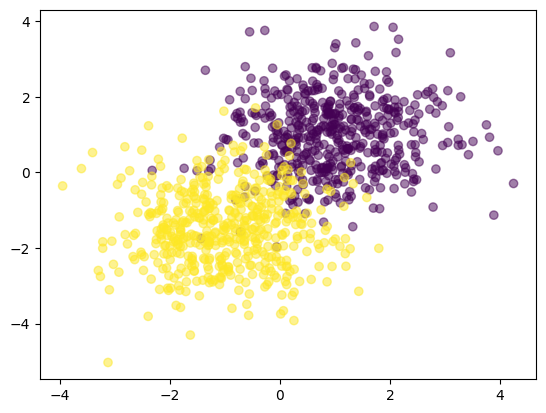

Training Accuracy: 0.9410


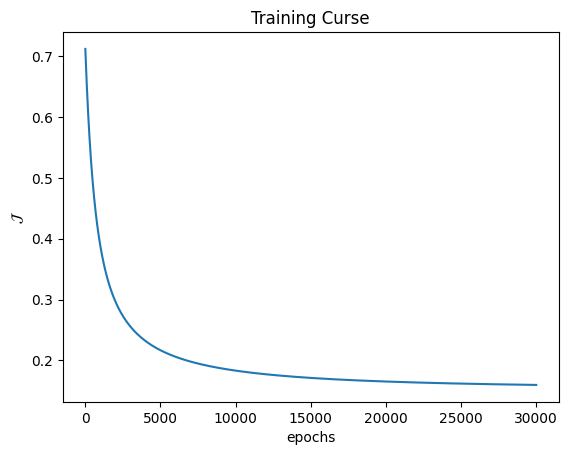

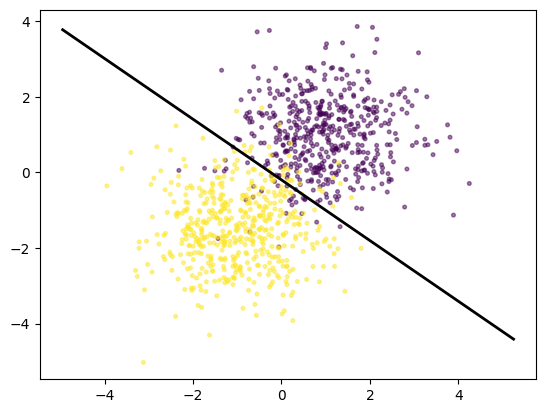

In [24]:
if __name__ == '__main__':
    main()